In [1]:
import numpy as np
np.set_printoptions(threshold=np.inf)
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import normflows as nf
import random
from torch.utils.data import DataLoader
import pandas as pd
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
import pyvinecopulib as pv

from scipy.stats import norm

from GPDFlow_S import S_mGPD_NF, ConditionalMaskedAffineFlow, ActNormConditional, ConditionalNormalizingFlow
import Common_Functions as cf
from matplotlib.colors import LinearSegmentedColormap
import scipy.stats as stats


Using device: cuda


#### Define a GPDFlow

In [2]:
dir_out = "/home/pgrad2/2448355h/My_PhD_Project/01_Output/GPDFlow/"

dim = 20


#### Find a suitable threshold for the simulated data

In [3]:
from scipy.stats import burr12

np.random.seed(42)
n_samples = 10000

# ── Burr XII marginal parameters ──────────────────────────────────────────────
# Burr XII CDF: F(x) = 1 - (1 + x^c)^{-k},  x > 0
# Tail index α = c*k  →  GPD shape γ ≈ 1/(c*k)
c_base = np.array([2.0, 3.0, 2.5, 1.5, 3.0])
k_base = np.array([1.5, 1.0, 2.0, 3.0, 3.5])
c_vals = np.tile(c_base, dim // len(c_base) + 1)[:dim]
k_vals = np.tile(k_base, dim // len(k_base) + 1)[:dim]

# ── One-factor Gumbel copula ─────────────────────────────────────────────────
# Latent V ~ U(0,1); each U_j is linked to V by its own bivariate Gumbel copula
# C_j(U_j, V; theta_j), so U_j | V is drawn through the Gumbel h-inverse.
# Joint copula:  C(u) = ∫_0^1 ∏_j F_{U_j|V}(u_j | v) dv.
# theta_j = 1 + s_j with s_j spaced evenly in the OPEN interval (0, 7), so
# theta_j in (1, 8): theta = 1 is independence, larger theta = stronger
# upper-tail dependence (chi_link = 2 - 2**(1/theta)).  The x7 scale spreads the
# induced pairwise chi across ~0.2-0.86 (theta in (1, 2) bunched it into
# 0.02-0.41).  Pair dependence is a function of (theta_i, theta_j), not lag.
theta = 1.0 + np.linspace(0, 7.0, dim + 2)[1:-1]        # (dim,) in (1, 8)

def simulate_factor_copula(n, thetas, seed=42):
    rng = np.random.default_rng(seed)
    V = rng.random(n)
    U = np.empty((n, len(thetas)))
    for j, th in enumerate(thetas):
        bicop = pv.Bicop(pv.BicopFamily.gumbel, parameters=np.array([[th]]))
        U[:, j] = bicop.hinv1(np.column_stack([V, rng.random(n)]))   # U_j | V
    return U                                            # shape (n, d), uniform

U = simulate_factor_copula(n_samples, theta, seed=42)

# Apply Burr XII marginals via inverse CDF
samples_origin = np.column_stack([
    burr12.ppf(U[:, j], c=c_vals[j], d=k_vals[j]) for j in range(dim)
])
print(f"Generated {n_samples} samples  |  shape: {samples_origin.shape}")

# ── True GPD parameters at the 95th-percentile threshold (fitted on large sample) ──
# For Burr XII the excess above a high threshold converges to a GPD;
# we obtain the limiting (σ, γ) numerically from a large independent Burr sample.
thres_q = 0.95
n_fit   = 200_000
true_sigma, true_gamma = [], []
for j in range(dim):
    big = burr12.rvs(c=c_vals[j], d=k_vals[j], size=n_fit, random_state=j)
    u_j = burr12.ppf(thres_q, c=c_vals[j], d=k_vals[j])
    exc = big[big > u_j] - u_j
    g, _, s = stats.genpareto.fit(exc, floc=0)
    true_gamma.append(g)
    true_sigma.append(s)

sigma = torch.tensor(true_sigma, dtype=torch.float32)
gamma = torch.tensor(true_gamma, dtype=torch.float32)
print(f"sigma = {sigma.numpy().round(3)}")
print(f"gamma = {gamma.numpy().round(3)}")

if dim == 2:
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.scatter(samples_origin[:, 0], samples_origin[:, 1], alpha=0.3, s=5, color='steelblue')
    ax.set_xlabel('$X_1$');  ax.set_ylabel('$X_2$')
    ax.set_title('One-factor Gumbel copula + Burr XII margins')
    plt.tight_layout();  plt.show()


Generated 10000 samples  |  shape: (10000, 20)
sigma = [0.97  0.916 0.413 0.505 0.18  0.956 0.91  0.407 0.514 0.175 0.982 0.918
 0.421 0.486 0.18  0.972 0.951 0.417 0.503 0.177]
gamma = [0.319 0.313 0.17  0.178 0.024 0.323 0.337 0.189 0.159 0.047 0.304 0.335
 0.15  0.197 0.014 0.322 0.311 0.167 0.186 0.029]


In [4]:
1/(3)

0.3333333333333333

In [4]:
# ── Reference pairwise chi of the one-factor Gumbel copula (large-sample MC) ──
# There is no simple closed form for the (i, j) pair chi of a one-factor Gumbel
# copula, so we take a large independent draw and use the rank-based estimator at
# a high level as the reference ("truth") for the diagnostic scatter plots below.
N_CHI_TRUTH = 500_000
U_chi_truth = simulate_factor_copula(N_CHI_TRUTH, theta, seed=42)
chi_theo = cf.pairwise_chi_from_data(U_chi_truth, p=0.999)     # (dim, dim), diag 1
chi_emp  = cf.pairwise_chi_from_data(samples_origin, p=0.999)

iu = np.triu_indices(dim, k=1)
chi_off = chi_theo[iu]
print(f"chi_ref off-diagonal | min {chi_off.min():.3f}  median {np.median(chi_off):.3f}  "
      f"max {chi_off.max():.3f}  sd {chi_off.std():.3f}")
print("theta_i  theta_j | chi_ref(MC) | chi_emp(q=0.99)")
order = np.argsort(chi_off)                                   # 10 pairs low -> high chi
for k in np.linspace(0, len(order) - 1, 10).astype(int):
    i, j = iu[0][order[k]], iu[1][order[k]]
    print(f"{theta[i]:6.2f}  {theta[j]:6.2f} | {chi_theo[i, j]:11.4f} | {chi_emp[i, j]:.4f}")
# chi_ref is a finite-level (q=0.99) rank estimate on 5e5 draws; the n=5000
# chi_emp sits near it up to sampling noise.


chi_ref off-diagonal | min 0.208  median 0.688  max 0.856  sd 0.167
theta_i  theta_j | chi_ref(MC) | chi_emp(q=0.99)
  1.33    1.67 |      0.2080 | 0.3000
  1.67    2.67 |      0.4300 | 0.4000
  2.00    4.00 |      0.5060 | 0.6000
  2.33    6.00 |      0.6120 | 0.7000
  2.67    6.00 |      0.6700 | 0.7000
  3.33    5.00 |      0.7140 | 0.6000
  3.67    7.67 |      0.7460 | 0.8000
  4.67    7.33 |      0.7880 | 0.9000
  5.67    7.33 |      0.8160 | 0.8000
  6.67    7.33 |      0.8560 | 0.9000


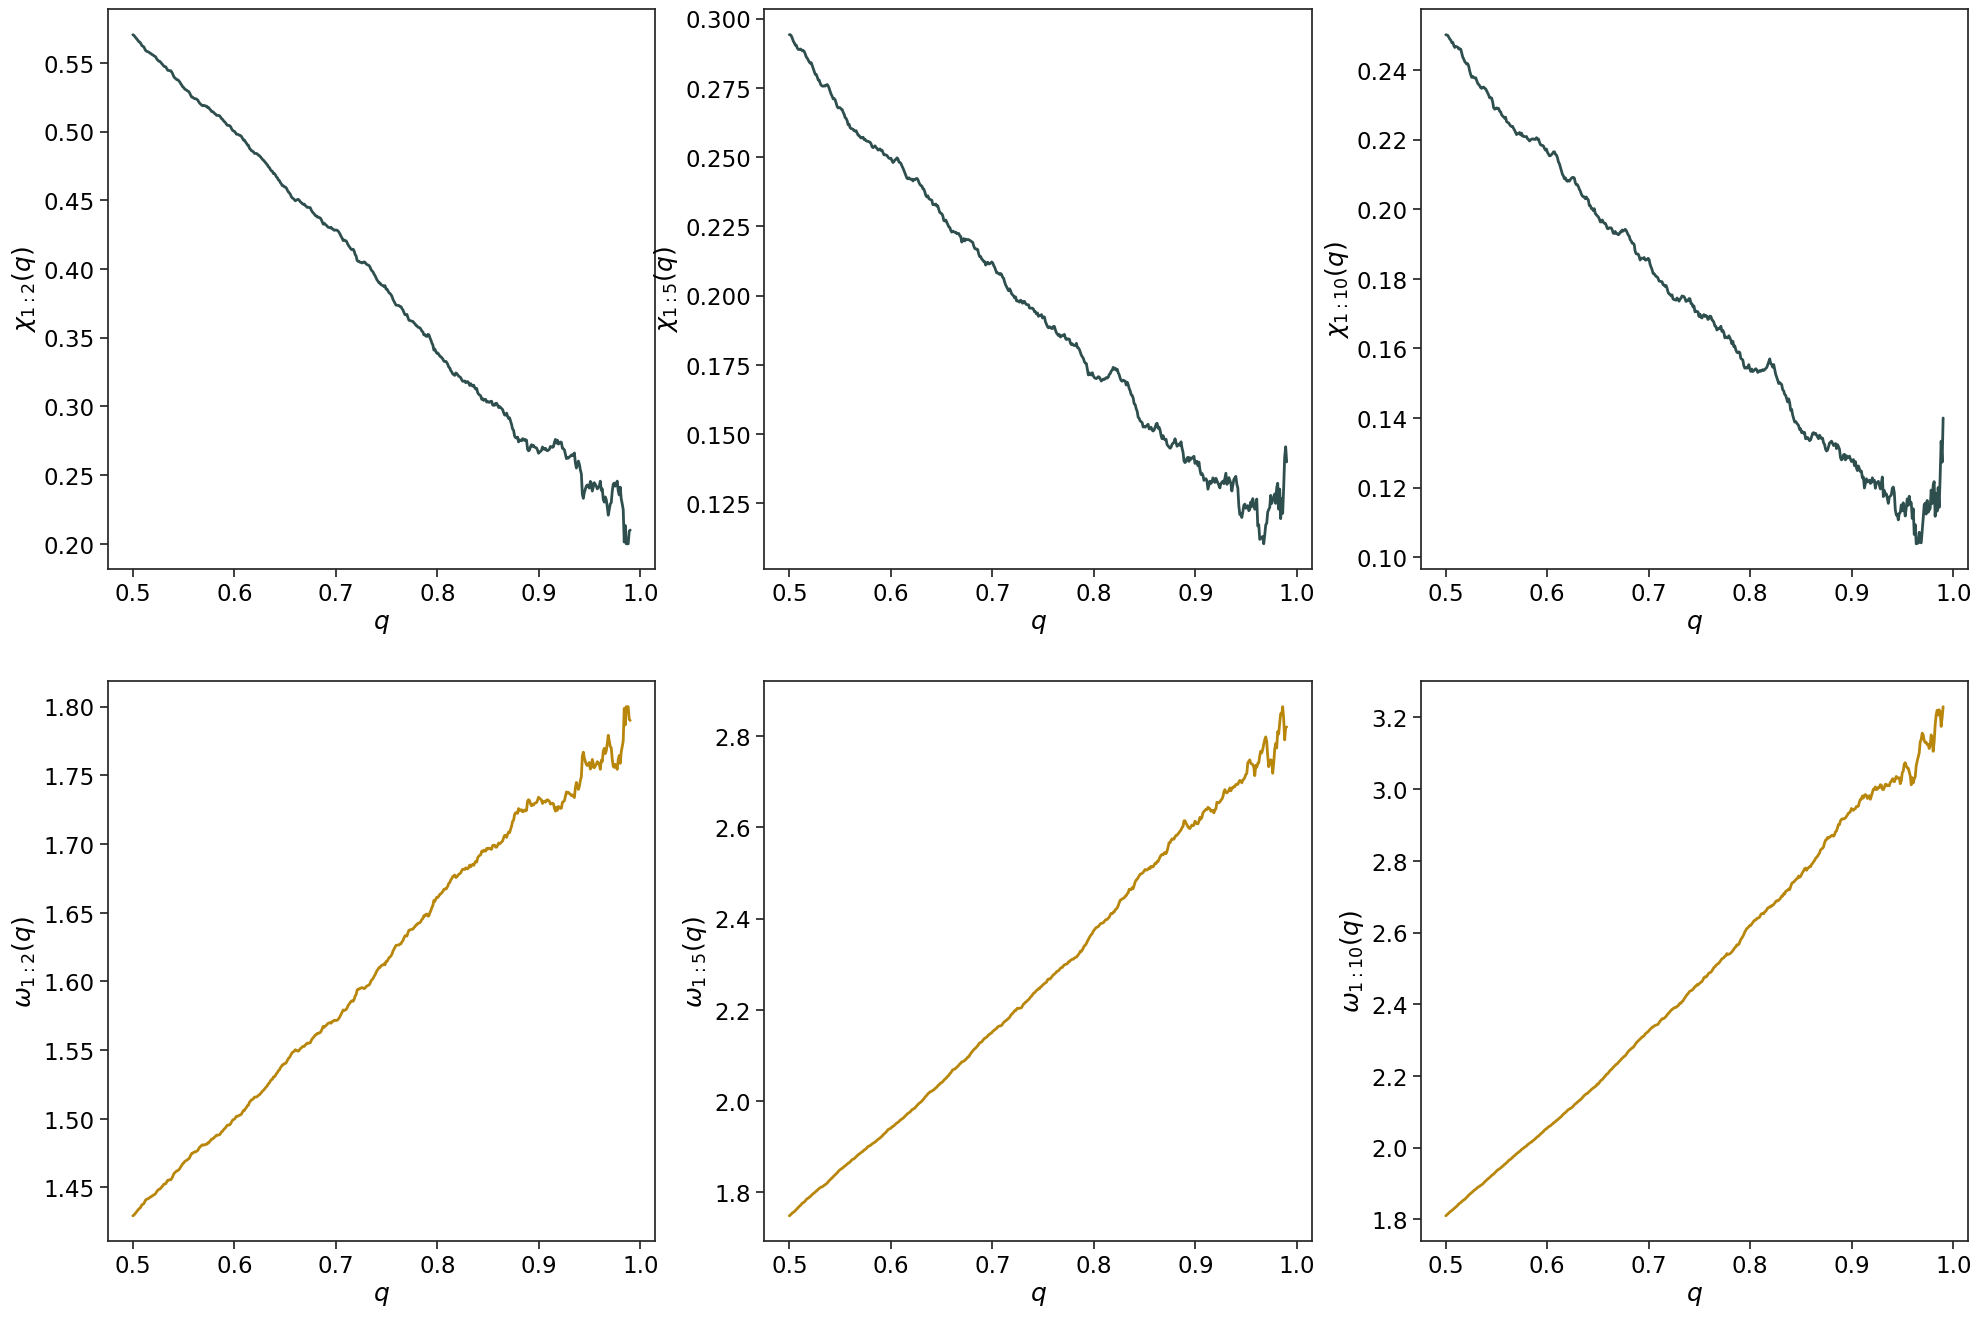

In [5]:
probs = np.linspace(0.5, 0.99, 500)
col_counts = [2, 5, 10]  # CHANGED: was 25 -- 22 columns after removing pegged currencies

chi_emp = {
    k: [cf.empirical_tail_dependence_measure(samples_origin[:, :k], p, 'and') for p in probs]
    for k in col_counts
}
omega_emp = {
    k: [cf.empirical_tail_dependence_measure(samples_origin[:, :k], p, 'or') for p in probs]
    for k in col_counts
}

# 2x3 grid: chi(q) on row 1, omega(q) on row 2, one column per subset size
sns.set(style="ticks", font_scale=1.5)
color_chi = 'darkslategray'
color_omega = 'darkgoldenrod'

fig, axes = plt.subplots(2, 3, figsize=(24, 16))

for col, k in enumerate(col_counts):
    ax = axes[0, col]
    ax.plot(probs, chi_emp[k], color=color_chi, linewidth=2)
    ax.set_xlabel(r'$q$', color='black')
    ax.set_ylabel(rf'$\chi_{{1:{k}}}(q)$', color='black')
    ax.tick_params(axis='both', labelcolor='black')

    ax = axes[1, col]
    ax.plot(probs, omega_emp[k], color=color_omega, linewidth=2)
    ax.set_xlabel(r'$q$', color='black')
    ax.set_ylabel(rf'$\omega_{{1:{k}}}(q)$', color='black')
    ax.tick_params(axis='both', labelcolor='black')


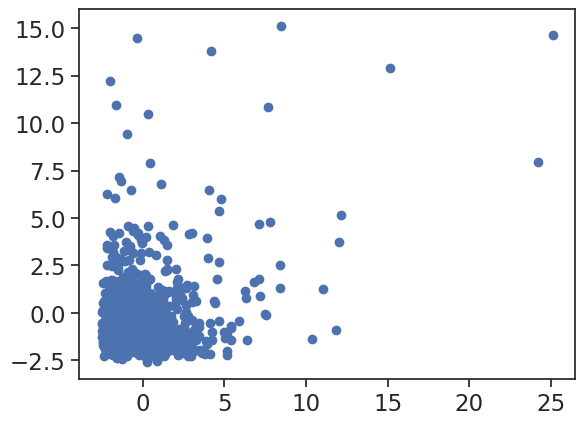

In [6]:
THRESHOLD_Q = 0.95

thres = np.quantile(samples_origin, THRESHOLD_Q, axis=0)

cond = np.any(samples_origin > thres, axis=1)
samples = samples_origin[cond,:]

thres = thres.reshape(1,-1)
samples = samples - thres

plt.scatter(samples[:,0],samples[:,1] )


In [7]:
samples.shape

(1561, 20)

In [8]:
# --- 5-fold cross-validation setup ------------------------------------------
import importlib
import cv_utils
importlib.reload(cv_utils)
from cv_utils import (
    make_folds,
    run_cv_gpdflow_likelihood,
    run_cv_gpdflow_mmd,
    run_cv_flow_baseline,
    run_cv_parametric_mgpd,
    build_probit_copula,
)

SMOKE = False                     # set True for a fast top-to-bottom check
EPOCHS_LIK = 5 if SMOKE else 500
EPOCHS_MMD = 5 if SMOKE else 500
EPOCHS_BL  = 5 if SMOKE else 400
EPOCHS_PAR = 5 if SMOKE else 300
SIM_MULT   = 50                   # simulated rows per fold = SIM_MULT * |fold k|


In [9]:
folds = make_folds(len(samples), n_splits=5, seed=1234)
print('fold val sizes:', [len(v) for _, v in folds])

fold val sizes: [313, 312, 312, 312, 312]


In [10]:
# --- Likelihood-based GPDFlow, 5-fold cross-validation ---------------------
# For fold k: train on the other 4 folds, early-stop on fold k (patience 100 on
# the validation NLL), then draw SIM_MULT * |fold k| observations from the
# fold-k model.  cv_utils keeps the 5 out-of-fold blocks SEPARATE
# (`samples_simu_folds`, raw scale) and computes NO tail-dependence summary --
# chi / omega are formed here, so the evaluation threshold can be changed
# without refitting.
THRESHOLD_Q = 0.999

dim = samples.shape[1]
p_cluster = samples.shape[0] / samples_origin.shape[0]
p_sim_q = 1.0 - (1.0 - THRESHOLD_Q) / p_cluster    # cluster-conditional level matching q = THRESHOLD_Q

# Shared flow / penalty config: used by BOTH the CV below and the final
# full-data fit, so the two can never drift (arch = hparam-sweep winner L4/lsf3).
LIK_CFG = dict(
    num_layers=4, latent_size_factor=3,
    penalty_lambda=1e4, marg_lambda=30,
    seed=1234,
)


def cv_pairwise_chi(fold_blocks, p):
    """Mean over CV folds of each fold model's rank-based pairwise chi at level p
    (folds are NOT pooled -- a pool of 5 separately fitted flows is a mixture)."""
    return np.mean([cf.pairwise_chi_from_data(b, p=p) for b in fold_blocks], axis=0)


def cv_pairwise_omega(fold_blocks, p):
    return np.mean([cf.pairwise_omega_from_data(b, p=p) for b in fold_blocks], axis=0)


cv_like = run_cv_gpdflow_likelihood(
    samples, folds, device, thres,
    epochs=EPOCHS_LIK, samples_multiplier=SIM_MULT,
    patience=100, **LIK_CFG,
    init_from_gpd= True
)

print('p_cluster =', round(p_cluster, 4), ' p_sim_q =', round(p_sim_q, 4))
print('per-fold best val NLL :', np.round(cv_like['best_vals'], 4))
print('per-fold best epoch   :', [h['best_epoch'] for h in cv_like['hist']])
print('fold-mean sigma_hat   :', np.round(cv_like['sigma_hat'], 3))
print('fold-mean gamma_hat   :', np.round(cv_like['gamma_hat'], 3))


[likelihood] fold 1/5 (train 1248, val 313)


  scipy margin init  gamma~[0.381 0.395 0.197 0.242 0.049 0.44  0.351 0.227 0.231 0.091 0.395 0.362
 0.246 0.27  0.036 0.384 0.369 0.213 0.252 0.038]
  scipy margin init  sigma~[1.05  0.922 0.456 0.492 0.188 0.945 1.007 0.42  0.539 0.174 0.917 0.968
 0.407 0.503 0.193 0.989 0.969 0.439 0.515 0.191]
  epoch    1/500 | train=34.9276 | val=29.4411 | val_nll=15.4107
  epoch   25/500 | train=24.6379 | val=21.4556 | val_nll=7.1420
  epoch   50/500 | train=22.6057 | val=20.1574 | val_nll=5.8828
  epoch   75/500 | train=21.8743 | val=20.2563 | val_nll=5.9507
  epoch  100/500 | train=20.9476 | val=20.0521 | val_nll=5.7386
  epoch  125/500 | train=20.4652 | val=20.4665 | val_nll=6.2606
  epoch  150/500 | train=19.5699 | val=20.9041 | val_nll=6.7130
  epoch  175/500 | train=19.0967 | val=20.9927 | val_nll=6.8253
  epoch  200/500 | train=18.2734 | val=22.1565 | val_nll=8.0373
  early stopping at epoch 204 (best val NLL @ 104).
[likelihood] fold 2/5 (train 1249, val 312)
  scipy margin init  gamma~

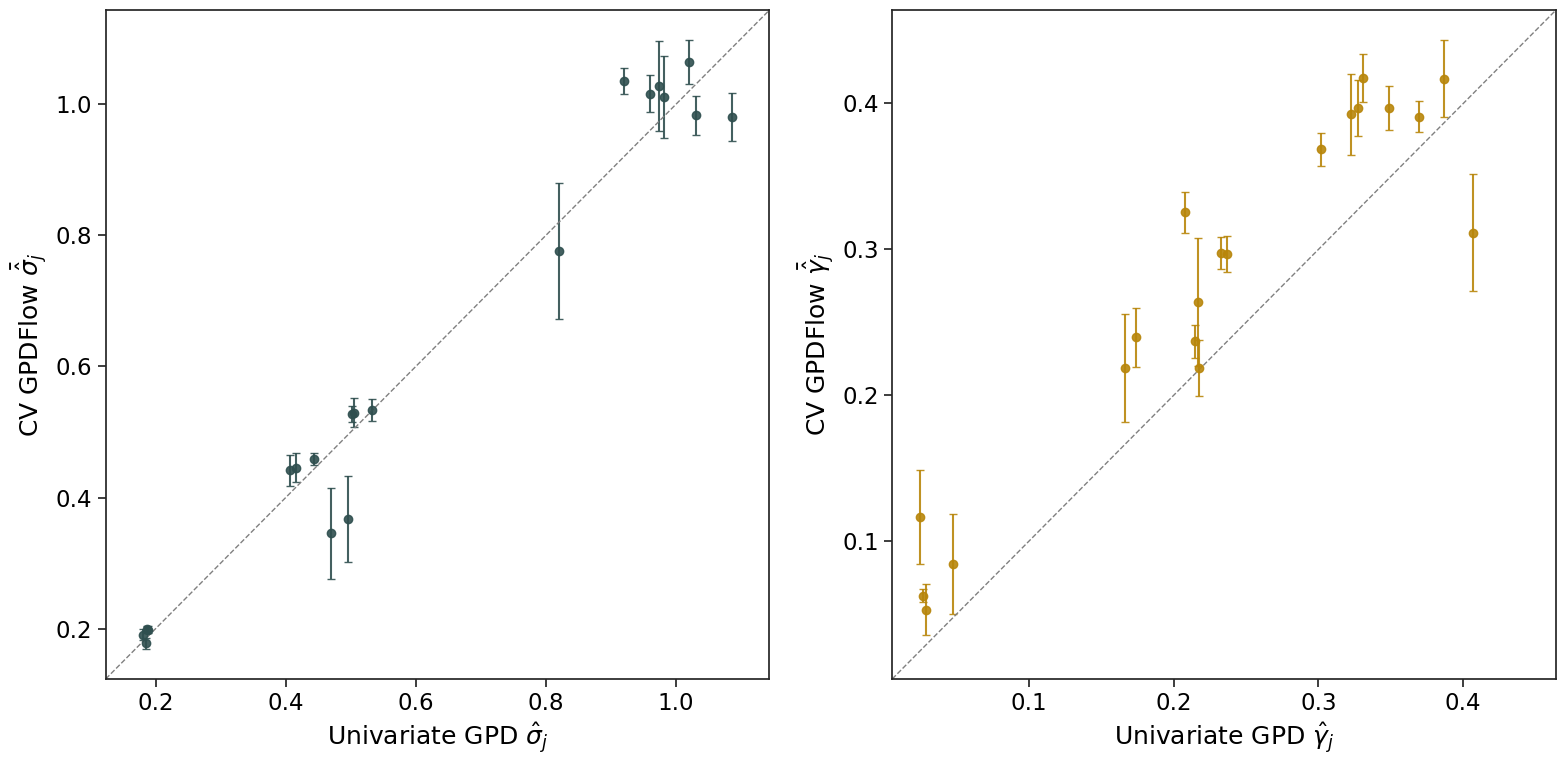

In [11]:
sigma_hat = cv_like['sigma_hat']
gamma_hat = cv_like['gamma_hat']
sigma_hat_folds = cv_like['sigma_hat_folds']
gamma_hat_folds = cv_like['gamma_hat_folds']

uni_sigmas = []
uni_gammas = []
for i in range(dim):
    data_i = samples[samples[:, i] > 0, i]
    c, loc, scale = stats.genpareto.fit(data_i, floc=0)
    uni_gammas.append(c)
    uni_sigmas.append(scale)
uni_sigmas = np.array(uni_sigmas)
uni_gammas = np.array(uni_gammas)

sns.set(style="ticks", font_scale=1.5)
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

ax = axes[0]
ax.errorbar(uni_sigmas, sigma_hat, yerr=sigma_hat_folds.std(axis=0),
            fmt='o', color='darkslategray', ecolor='darkslategray',
            alpha=0.9, capsize=3)
lims = [min(*ax.get_xlim(), *ax.get_ylim()), max(*ax.get_xlim(), *ax.get_ylim())]
ax.plot(lims, lims, color='gray', linestyle='--', linewidth=1)
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel(r'Univariate GPD $\hat{\sigma}_j$', color='black')
ax.set_ylabel(r'CV GPDFlow $\bar{\hat{\sigma}}_j$', color='black')
ax.tick_params(axis='both', labelcolor='black')

ax = axes[1]
ax.errorbar(uni_gammas, gamma_hat, yerr=gamma_hat_folds.std(axis=0),
            fmt='o', color='darkgoldenrod', ecolor='darkgoldenrod',
            alpha=0.9, capsize=3)
lims = [min(*ax.get_xlim(), *ax.get_ylim()), max(*ax.get_xlim(), *ax.get_ylim())]
ax.plot(lims, lims, color='gray', linestyle='--', linewidth=1)
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel(r'Univariate GPD $\hat{\gamma}_j$', color='black')
ax.set_ylabel(r'CV GPDFlow $\bar{\hat{\gamma}}_j$', color='black')
ax.tick_params(axis='both', labelcolor='black')

fig.tight_layout()
plt.show()

p_sim_q          : 0.9936
RMSE chi         : 0.0626
TDE  chi         : 0.0421
mean signed bias : +0.0172


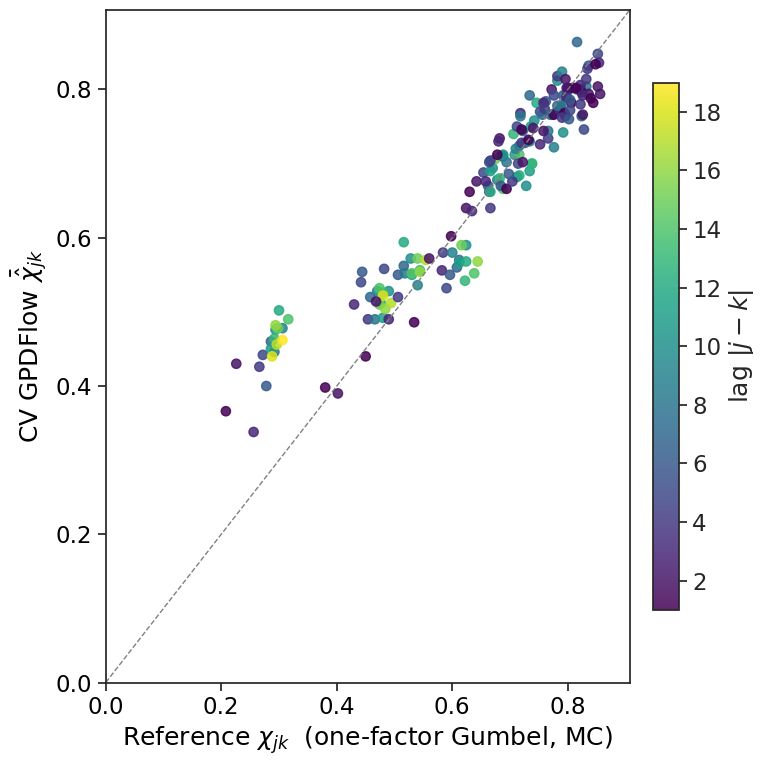

In [12]:
# --- Estimated vs reference pairwise chi -------------------------------------
# Estimated chi = mean over the 5 CV fold models of each fold's rank-based
# pairwise chi of its simulated draws (folds NOT pooled -- a pool of 5 flows is a
# mixture, not an mGPD), evaluated at the cluster-conditional level p_sim_q.
# Reference chi = one-factor Gumbel copula, large-sample MC (cell 5).

chi_hat_mat  = cv_pairwise_chi(cv_like['samples_simu_folds'], p_sim_q)   # (dim, dim)
chi_theo_mat = chi_theo        # one-factor Gumbel, large-sample MC reference (cell 5)

iu = np.triu_indices(dim, k=1)
chi_hat_pairs  = chi_hat_mat[iu]
chi_theo_pairs = chi_theo_mat[iu]
lag_pairs      = iu[1] - iu[0]                                           # |j - k|

print(f'p_sim_q          : {p_sim_q:.4f}')
print(f'RMSE chi         : {cf.rmse_chi(chi_hat_pairs, chi_theo_pairs):.4f}')
print(f'TDE  chi         : {cf.tde_chi(chi_hat_mat, chi_theo_mat):.4f}')
print(f'mean signed bias : {(chi_hat_pairs - chi_theo_pairs).mean():+.4f}')

sns.set(style="ticks", font_scale=1.5)
fig, ax = plt.subplots(figsize=(8, 8))

sc = ax.scatter(chi_theo_pairs, chi_hat_pairs, c=lag_pairs, cmap='viridis',
                alpha=0.85, s=45)
lims = [0.0, max(chi_theo_pairs.max(), chi_hat_pairs.max()) * 1.05]
ax.plot(lims, lims, color='gray', linestyle='--', linewidth=1)
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel(r'Reference $\chi_{jk}$  (one-factor Gumbel, MC)', color='black')
ax.set_ylabel(r'CV GPDFlow $\bar{\hat{\chi}}_{jk}$', color='black')
ax.tick_params(axis='both', labelcolor='black')
cb = fig.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)
cb.set_label(r'lag $|j-k|$')

fig.tight_layout()
plt.show()


#### MMD based estimation

In [13]:
MMD_CFG = dict(
    warmup_epochs=50, min_delta=1e-3,
    penalty_lambda=1e4, mmd_lambda=15, mmd_samples_per_face=128,
    mmd_censor_c=0, mmd_censor_tau=0.1,
    mmd_indicator_alpha=5, mmd_indicator_rho=3,
    num_layers=4, latent_size_factor=2,
    seed=1234,
)

cv_mmd = run_cv_gpdflow_mmd(
    samples, folds, device, thres,
    epochs=EPOCHS_MMD, samples_multiplier=SIM_MULT,
    patience=100, **MMD_CFG,
)
dim_2s = cv_mmd['dim_2s']

print('per-fold best val loss :', np.round(cv_mmd['best_vals'], 4))
print('per-fold best epoch    :', [h['best_epoch'] for h in cv_mmd['hist']])
print('dropped train rows/fold:', cv_mmd['dropped_rows_train'])
print('dropped val rows/fold  :', cv_mmd['dropped_rows_val'])


[mmd] fold 1/5 (train 1248/1248, val 313/313)
  epoch    1/500 | train=4.1256 | val=3.5261
  epoch   25/500 | train=0.2228 | val=0.2363
  epoch   50/500 | train=0.1539 | val=0.1584
  epoch   75/500 | train=0.0889 | val=0.1149
  epoch  100/500 | train=0.0401 | val=0.1182
  epoch  125/500 | train=0.0771 | val=0.1440
  epoch  150/500 | train=-0.0162 | val=0.1410
  epoch  175/500 | train=-0.0384 | val=0.1249
  epoch  200/500 | train=0.1074 | val=0.0673
  epoch  225/500 | train=0.0030 | val=0.0630
  epoch  250/500 | train=-0.0105 | val=0.0927
  epoch  275/500 | train=-0.0155 | val=0.0699
  epoch  300/500 | train=0.0742 | val=0.0454
  epoch  325/500 | train=0.0224 | val=0.1150
  epoch  350/500 | train=-0.0542 | val=0.0837
  epoch  375/500 | train=-0.0285 | val=0.0504
  epoch  400/500 | train=-0.0573 | val=0.0346
  epoch  425/500 | train=-0.0311 | val=0.0485
  epoch  450/500 | train=-0.0158 | val=0.0460
  epoch  475/500 | train=0.1733 | val=0.0525
  epoch  500/500 | train=-0.0449 | val=0.0644

p_sim_q          : 0.9936
RMSE chi         : 0.0525
TDE  chi         : 0.0422
mean signed bias : +0.0411


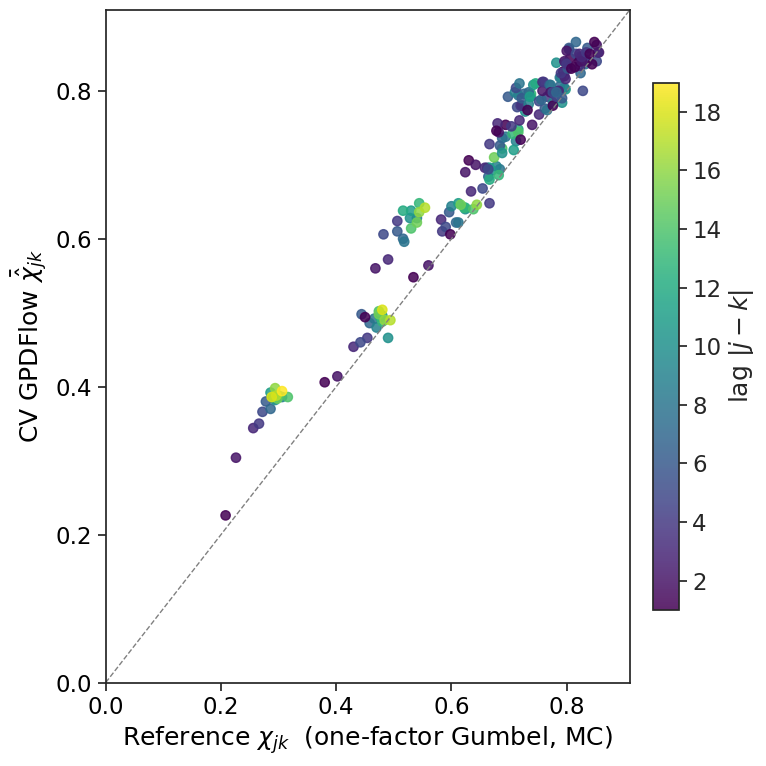

In [14]:
chi_hat_mat  = cv_pairwise_chi(cv_mmd['samples_simu_2s_folds'], p_sim_q)   # (dim, dim)
chi_theo_mat = chi_theo        # one-factor Gumbel, large-sample MC reference (cell 5)

iu = np.triu_indices(dim, k=1)
chi_hat_pairs  = chi_hat_mat[iu]
chi_theo_pairs = chi_theo_mat[iu]
lag_pairs      = iu[1] - iu[0]                                           # |j - k|

print(f'p_sim_q          : {p_sim_q:.4f}')
print(f'RMSE chi         : {cf.rmse_chi(chi_hat_pairs, chi_theo_pairs):.4f}')
print(f'TDE  chi         : {cf.tde_chi(chi_hat_mat, chi_theo_mat):.4f}')
print(f'mean signed bias : {(chi_hat_pairs - chi_theo_pairs).mean():+.4f}')

sns.set(style="ticks", font_scale=1.5)
fig, ax = plt.subplots(figsize=(8, 8))

sc = ax.scatter(chi_theo_pairs, chi_hat_pairs, c=lag_pairs, cmap='viridis',
                alpha=0.85, s=45)
lims = [0.0, max(chi_theo_pairs.max(), chi_hat_pairs.max()) * 1.05]
ax.plot(lims, lims, color='gray', linestyle='--', linewidth=1)
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel(r'Reference $\chi_{jk}$  (one-factor Gumbel, MC)', color='black')
ax.set_ylabel(r'CV GPDFlow $\bar{\hat{\chi}}_{jk}$', color='black')
ax.tick_params(axis='both', labelcolor='black')
cb = fig.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)
cb.set_label(r'lag $|j-k|$')

fig.tight_layout()
plt.show()


In [15]:
BL_CFG = dict(warmup=20, seed=0, num_layers = 6, hidden_mult = 4)

cv_bl = run_cv_flow_baseline(
    samples, folds, device, thres,
    epochs=EPOCHS_BL, samples_multiplier=SIM_MULT,
    patience=40, **BL_CFG,
)
flow_baseline = cv_bl['models'][-1]              # last fold's flow, for the diagnostics below
print('per-fold best val NLL:', np.round(cv_bl['best_vals'], 4))
print('per-fold best epoch  :', [h['best_epoch'] for h in cv_bl['hist']])

[baseline] fold 1/5 (train 1248, val 313)
  epoch    1/400 | train_nll=27.643 | val_nll=25.419
  epoch   25/400 | train_nll=10.739 | val_nll=10.220
  epoch   50/400 | train_nll=9.970 | val_nll=9.911
  epoch   75/400 | train_nll=9.670 | val_nll=9.968
  early stopping at epoch 91 (best val NLL @ 51).
[baseline] fold 2/5 (train 1249, val 312)
  epoch    1/400 | train_nll=28.119 | val_nll=25.932
  epoch   25/400 | train_nll=10.676 | val_nll=10.517
  epoch   50/400 | train_nll=9.905 | val_nll=10.126
  epoch   75/400 | train_nll=9.566 | val_nll=10.240
  early stopping at epoch 90 (best val NLL @ 50).
[baseline] fold 3/5 (train 1249, val 312)
  epoch    1/400 | train_nll=27.484 | val_nll=25.383
  epoch   25/400 | train_nll=10.549 | val_nll=10.700
  epoch   50/400 | train_nll=9.817 | val_nll=10.489
  epoch   75/400 | train_nll=9.468 | val_nll=10.671
  early stopping at epoch 84 (best val NLL @ 44).
[baseline] fold 4/5 (train 1249, val 312)
  epoch    1/400 | train_nll=27.623 | val_nll=25.721
 

p_sim_q          : 0.9936
RMSE chi         : 0.0791
TDE  chi         : 0.0746
mean signed bias : -0.0746


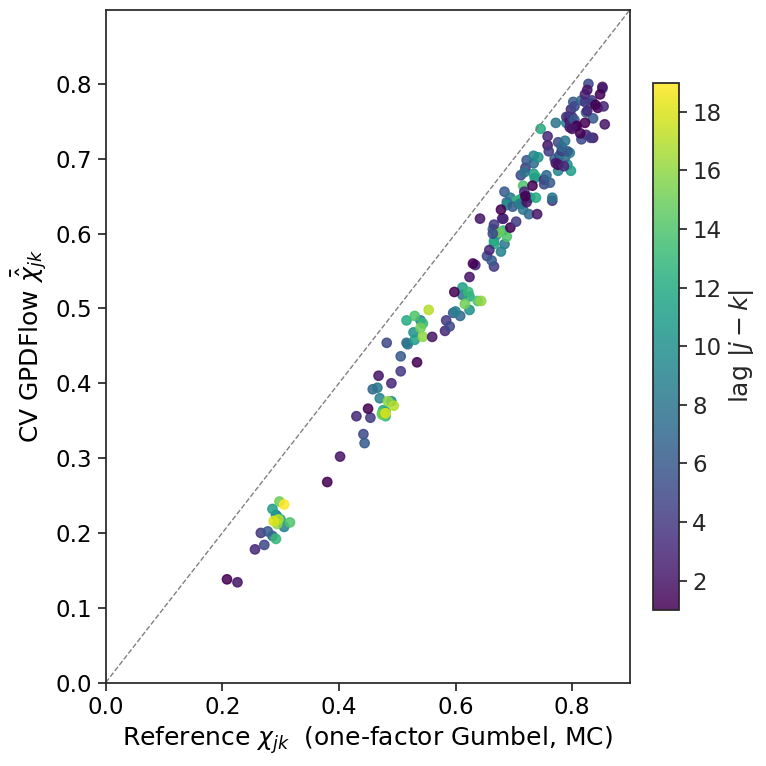

In [16]:
chi_hat_mat  = cv_pairwise_chi(cv_bl['samples_simu_bl_folds'], p_sim_q)   # (dim, dim)
chi_theo_mat = chi_theo        # one-factor Gumbel, large-sample MC reference (cell 5)

iu = np.triu_indices(dim, k=1)
chi_hat_pairs  = chi_hat_mat[iu]
chi_theo_pairs = chi_theo_mat[iu]
lag_pairs      = iu[1] - iu[0]                                           # |j - k|

print(f'p_sim_q          : {p_sim_q:.4f}')
print(f'RMSE chi         : {cf.rmse_chi(chi_hat_pairs, chi_theo_pairs):.4f}')
print(f'TDE  chi         : {cf.tde_chi(chi_hat_mat, chi_theo_mat):.4f}')
print(f'mean signed bias : {(chi_hat_pairs - chi_theo_pairs).mean():+.4f}')

sns.set(style="ticks", font_scale=1.5)
fig, ax = plt.subplots(figsize=(8, 8))

sc = ax.scatter(chi_theo_pairs, chi_hat_pairs, c=lag_pairs, cmap='viridis',
                alpha=0.85, s=45)
lims = [0.0, max(chi_theo_pairs.max(), chi_hat_pairs.max()) * 1.05]
ax.plot(lims, lims, color='gray', linestyle='--', linewidth=1)
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel(r'Reference $\chi_{jk}$  (one-factor Gumbel, MC)', color='black')
ax.set_ylabel(r'CV GPDFlow $\bar{\hat{\chi}}_{jk}$', color='black')
ax.tick_params(axis='both', labelcolor='black')
cb = fig.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)
cb.set_label(r'lag $|j-k|$')

fig.tight_layout()
plt.show()


### Parametric mGPD 

In [17]:
import importlib
import parametric_mGPD
importlib.reload(parametric_mGPD)  # pick up edits without a kernel restart
from parametric_mGPD import (
    ParametricMGPD,
    GENERATORS,
    fit_parametric_mgpd,
    support_mask,
)


In [18]:
PAR_CFG = dict(generator='gaussian', seed=1234)

cv_par = run_cv_parametric_mgpd(
    samples, folds, device, thres,
    epochs=EPOCHS_PAR, samples_multiplier=SIM_MULT, **PAR_CFG,
)
print('per-fold best val NLL [par]:', np.round(cv_par['best_vals'], 4))
print('per-fold best epoch   [par]:', [h['best_epoch'] for h in cv_par['hist']])

chi_true_par = cf.pairwise_chi_from_data(samples_origin, p=THRESHOLD_Q)
chi_hat_par_cv = cv_pairwise_chi(cv_par['samples_simu_par_folds'], p_sim_q)
print('Traditional mGPD   tde_chi (CV):',
      round(cf.tde_chi(chi_hat_par_cv, chi_true_par), 4))

[parametric:gaussian] fold 1/5 (train 1248, val 313)


  [gaussian  ] ep   0  batch loss     20.019   val NLL    19.943   (best    19.943)
  [gaussian  ] ep  50  batch loss      2.135   val NLL     1.876   (best     1.876)
  [gaussian  ] ep 100  batch loss      1.631   val NLL     1.489   (best     1.451)
  [gaussian  ] ep 150  batch loss      1.544   val NLL     1.374   (best     1.351)
  [gaussian  ] ep 200  batch loss      2.458   val NLL     1.310   (best     1.306)
  [gaussian  ] ep 250  batch loss      1.714   val NLL     1.286   (best     1.286)
  [gaussian  ] ep 299  batch loss      1.021   val NLL     1.285   (best     1.285)
[parametric:gaussian] fold 2/5 (train 1249, val 312)
  [gaussian  ] ep   0  batch loss     21.220   val NLL    20.494   (best    20.494)
  [gaussian  ] ep  50  batch loss      2.627   val NLL     2.645   (best     2.643)
  [gaussian  ] ep 100  batch loss      1.896   val NLL     2.278   (best     2.258)
  [gaussian  ] ep 150  batch loss      1.604   val NLL     2.111   (best     2.111)
  [gaussian  ] ep 200  

p_sim_q          : 0.9936
RMSE chi         : 0.1381
TDE  chi         : 0.1264
mean signed bias : -0.1264


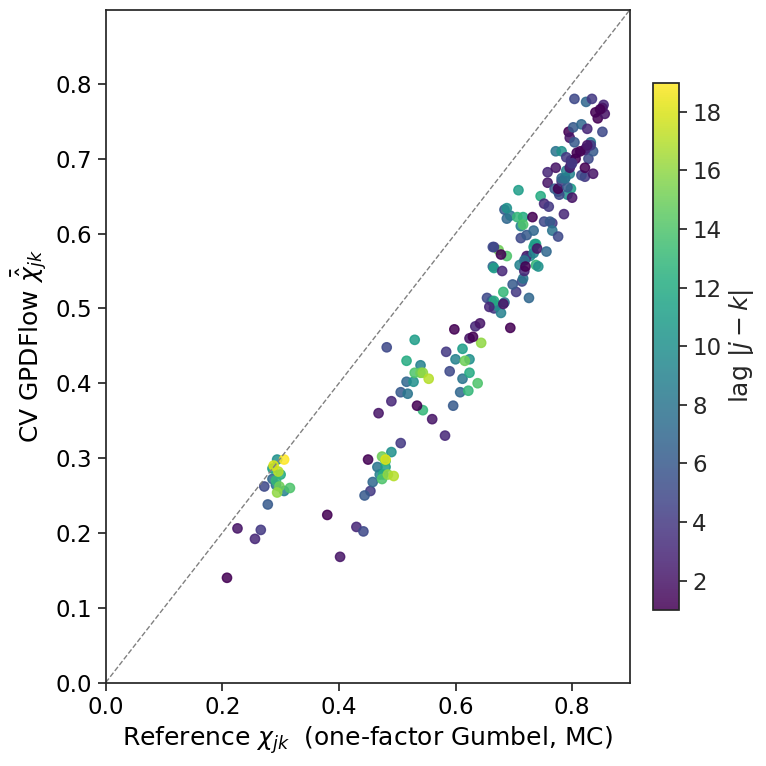

In [19]:
chi_hat_mat  = cv_pairwise_chi(cv_par['samples_simu_par_folds'], p_sim_q)   # (dim, dim)
chi_theo_mat = chi_theo        # one-factor Gumbel, large-sample MC reference (cell 5)

iu = np.triu_indices(dim, k=1)
chi_hat_pairs  = chi_hat_mat[iu]
chi_theo_pairs = chi_theo_mat[iu]
lag_pairs      = iu[1] - iu[0]                                           # |j - k|

print(f'p_sim_q          : {p_sim_q:.4f}')
print(f'RMSE chi         : {cf.rmse_chi(chi_hat_pairs, chi_theo_pairs):.4f}')
print(f'TDE  chi         : {cf.tde_chi(chi_hat_mat, chi_theo_mat):.4f}')
print(f'mean signed bias : {(chi_hat_pairs - chi_theo_pairs).mean():+.4f}')

sns.set(style="ticks", font_scale=1.5)
fig, ax = plt.subplots(figsize=(8, 8))

sc = ax.scatter(chi_theo_pairs, chi_hat_pairs, c=lag_pairs, cmap='viridis',
                alpha=0.85, s=45)
lims = [0.0, max(chi_theo_pairs.max(), chi_hat_pairs.max()) * 1.05]
ax.plot(lims, lims, color='gray', linestyle='--', linewidth=1)
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel(r'Reference $\chi_{jk}$  (one-factor Gumbel, MC)', color='black')
ax.set_ylabel(r'CV GPDFlow $\bar{\hat{\chi}}_{jk}$', color='black')
ax.tick_params(axis='both', labelcolor='black')
cb = fig.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)
cb.set_label(r'lag $|j-k|$')

fig.tight_layout()
plt.show()


### Far-tail quantities: large-MC "truth" vs the fitted models

For a large fresh **unconditional** Monte-Carlo draw from the DGP (the "true" value) and
for the **cluster-conditional** draws of each fitted model (the "estimated" value,
adjusted to the unconditional scale via the POT/mGPD decomposition,
CLAUDE.md Sec 2.4), compute and compare:

1. marginal quantiles at the `q = 0.9999` level, one per dimension;
2. `P(exactly K_EXCEED of the d components exceed their level-q marginal quantile)`
   as a function of `q`, for a chosen number of simultaneously exceeding
   components `K_EXCEED` (`K_EXCEED = dim` gives "all d components exceed").

Adjustment: a cluster-implied event `A` has `P(A) = p_cluster · P_model(A | cluster)`;
a quantile level `q` asked of the model is read off at `p_sim = 1 − (1−q)/p_cluster`.


In [20]:
# ============================================================================
# Setup: large-MC "truth" sample + shared config for the far-tail quantities
# ============================================================================
Q_SLICE = 0.95          # quantile level that built `samples` / `thres` (cell "dedddfd6").
                        # NB the module-level THRESHOLD_Q was overwritten to 0.999 later on.
N_BIG   = 2_000_000     # raise (e.g. 5_000_000) if the "all d" curve floors out at ~1/N_BIG
Q_MARG  = 0.9999        # marginal-quantile level for quantity 1

p_cluster_fit = samples.shape[0] / samples_origin.shape[0]     # P(exceedance cluster)
p_sim_marg    = 1.0 - (1.0 - Q_MARG) / p_cluster_fit           # model's own-quantile level
assert 0.0 < p_sim_marg < 1.0, p_sim_marg

# Fresh unconditional MC draw from the same one-factor Gumbel + Burr XII DGP as
# cell "229e9ac7" (independent seed).
U_big = simulate_factor_copula(N_BIG, theta, seed=20260908)
cols  = [burr12.ppf(U_big[:, j], c=c_vals[j], d=k_vals[j]).astype(np.float32)
         for j in range(dim)]
del U_big
X_big = np.column_stack(cols)
del cols

thres_row = np.asarray(thres, dtype=float).reshape(-1)         # (dim,)
print(f'X_big {X_big.shape}  |  p_cluster(fit) = {p_cluster_fit:.4f}  '
      f'|  p_cluster(X_big) = {float((X_big > thres_row).any(1).mean()):.4f}')

# A single common *absolute* threshold does not exist here (the Burr XII margins
# have very different tail indices), so quantities 2 & 3 use a per-margin
# threshold vector at a common probability level q: u_j(q) = Q_j(q).  For any
# q >= Q_SLICE, exceeding u_j(q) implies the cluster event, so the SAME u_vec(q)
# serves the truth (directly) and every model (x p_cluster).
#
# q ranges from Q_SLICE (0.95) to 0.999, geometrically dense in the tail
# probability 1 - q so the far tail -- where the joint-exceedance probability
# decays over several orders of magnitude -- is well resolved on a log axis.
Q_GRID = 1.0 - np.geomspace(1.0 - Q_SLICE, 1e-4, 80)           # 0.95 .. 0.999
U_MATS = [np.quantile(X_big, q, axis=0) for q in Q_GRID]       # list of (dim,) vectors

MODELS = [   # (label, per-fold raw-scale draw blocks, colour)
    ('GPDFlow (likelihood)',    cv_like['samples_simu_folds'],    'darkgoldenrod'),
    ('GPDFlow (MMD, two-stage)', cv_mmd['samples_simu_2s_folds'],  'firebrick'),
    ('Probit-copula RealNVP',    cv_bl['samples_simu_bl_folds'],   'steelblue'),
    ('Parametric mGPD',          cv_par['samples_simu_par_folds'], 'seagreen'),
]
TRUTH_C = 'darkslategray'


X_big (2000000, 20)  |  p_cluster(fit) = 0.1561  |  p_cluster(X_big) = 0.1614


In [21]:
# --- helper functions: far-tail quantities, truth + cluster-adjusted model ---
def _finite(X):
    X = np.asarray(X, dtype=float)
    return X[np.isfinite(X).all(axis=1)]


def marginal_quantiles_true(X_big, q):
    """Unconditional marginal q-quantile of every margin -- shape (dim,)."""
    return np.quantile(X_big, q, axis=0)


def marginal_quantiles_model(fold_blocks, p_cluster, q, combine='pool'):
    """Model estimate of the unconditional marginal q-quantile.

    The draws are cluster-conditional, so the unconditional q-quantile equals the
    draws' p_sim-quantile with p_sim = 1 - (1 - q) / p_cluster.
        combine='pool' : one quantile over the 5 fold blocks stacked (needed at
                         q = 0.9999, where a single fold has ~30 draws above p_sim);
        combine='mean' : per-fold quantile, then averaged (folds not pooled).
    Returns (estimate (dim,), per_fold (n_folds, dim) or None).
    """
    p_sim = 1.0 - (1.0 - q) / p_cluster
    if not 0.0 < p_sim < 1.0:
        raise ValueError(f'p_sim={p_sim:.4g} outside (0,1): p_cluster too small for q={q}')
    if combine == 'pool':
        return np.quantile(_finite(np.vstack(fold_blocks)), p_sim, axis=0), None
    per = np.array([np.quantile(_finite(b), p_sim, axis=0) for b in fold_blocks])
    return per.mean(axis=0), per


def prob_all_exceed(X, u_vec):
    """P(all d margins exceed the per-margin threshold vector u_vec)."""
    Xf = _finite(X)
    return cf.simultaneous_exceedance_probability(Xf, u_vec, Xf.shape[1] - 1)


def prob_exactly_k_exceed(X, u_vec, k):
    """P(exactly k of d margins exceed u_vec) = P(#>k-1) - P(#>k)."""
    Xf = _finite(X)
    return (cf.simultaneous_exceedance_probability(Xf, u_vec, k - 1)
            - cf.simultaneous_exceedance_probability(Xf, u_vec, k))


def prob_curve_true(X_big, u_mats, fn):
    """fn evaluated on the large unconditional sample at every u_vec in u_mats."""
    return np.array([fn(X_big, u) for u in u_mats])


def prob_curve_model(fold_blocks, p_cluster, u_mats, fn):
    """Cluster-adjusted model curve: mean over folds of p_cluster * P_model(. | cluster).

    Returns (fold_mean_curve (len(u_mats),), per_fold_curves (n_folds, len(u_mats))).
    """
    per = np.array([[p_cluster * fn(b, u) for u in u_mats] for b in fold_blocks])
    return per.mean(axis=0), per


def max_component_quantile(X, q, p_cluster=1.0):
    """q-quantile of the componentwise maximum  M = max_j X_j.

    p_cluster == 1 : X is an unconditional sample -> plain q-quantile of M.
    p_cluster < 1  : X is cluster-conditional (>=1 margin over its threshold);
                     the unconditional q-quantile of M equals the draws'
                     p_sim-quantile, p_sim = 1 - (1 - q) / p_cluster -- exact
                     while Q_M(q) >= max_j thres_j (there {M > x} => cluster).
    q may be a scalar or an array; the return matches its shape.
    """
    M = _finite(X).max(axis=1)
    p_sim = 1.0 - (1.0 - np.asarray(q, dtype=float)) / p_cluster
    return np.quantile(M, np.clip(p_sim, 0.0, 1.0))


marginal q = 0.9999 quantile   |   RMSE(log scale) vs truth
  GPDFlow (likelihood)     : 0.3447
  GPDFlow (MMD, two-stage) : 0.0908
  Probit-copula RealNVP    : 0.2572
  Parametric mGPD          : 0.6933


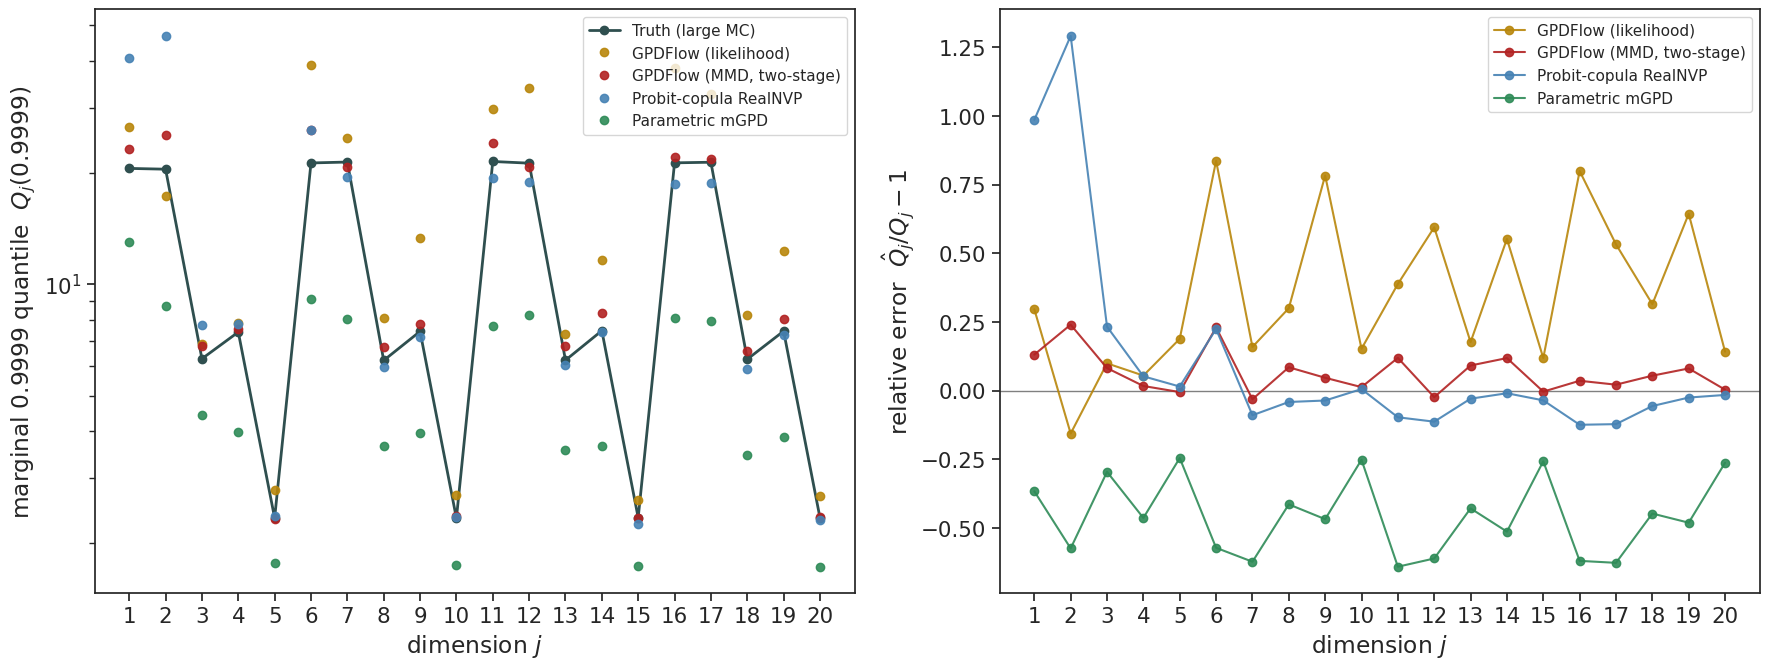

In [22]:
# --- Quantity 1: marginal quantiles at q = 0.9999, all dimensions -----------
q_true = marginal_quantiles_true(X_big, Q_MARG)

dims_ax = np.arange(1, dim + 1)
model_q = []
print(f'marginal q = {Q_MARG} quantile   |   RMSE(log scale) vs truth')
for label, blocks, color in MODELS:
    q_hat, _ = marginal_quantiles_model(blocks, p_cluster_fit, Q_MARG, combine='pool')
    model_q.append((label, q_hat, color))
    print(f'  {label:24s} : {cf.rmse_log_sigma(q_hat, q_true):.4f}')

sns.set(style='ticks', font_scale=1.4)
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

ax = axes[0]
ax.plot(dims_ax, q_true, '-o', color=TRUTH_C, lw=2, label='Truth (large MC)')
for label, q_hat, color in model_q:
    ax.plot(dims_ax, q_hat, 'o', color=color, alpha=0.9, label=label)
ax.set_yscale('log')
ax.set_xlabel('dimension $j$')
ax.set_ylabel(rf'marginal ${Q_MARG}$ quantile  $Q_j({Q_MARG})$')
ax.set_xticks(dims_ax)
ax.legend(fontsize=11)

ax = axes[1]
ax.axhline(0.0, color='gray', lw=1)
for label, q_hat, color in model_q:
    ax.plot(dims_ax, q_hat / q_true - 1.0, 'o-', color=color, alpha=0.9, label=label)
ax.set_xlabel('dimension $j$')
ax.set_ylabel(r'relative error  $\hat Q_j / Q_j - 1$')
ax.set_xticks(dims_ax)
ax.legend(fontsize=11)

fig.tight_layout()
plt.show(


P(exactly 5 of 20 exceed):
  model                         LJPE   RMSLE_p   (over q where truth > 0)
  GPDFlow (likelihood)        0.6547    0.8213
  GPDFlow (MMD, two-stage)    0.2116    0.3073
  Probit-copula RealNVP       0.4164    0.4789
  Parametric mGPD             5.1912    8.4323


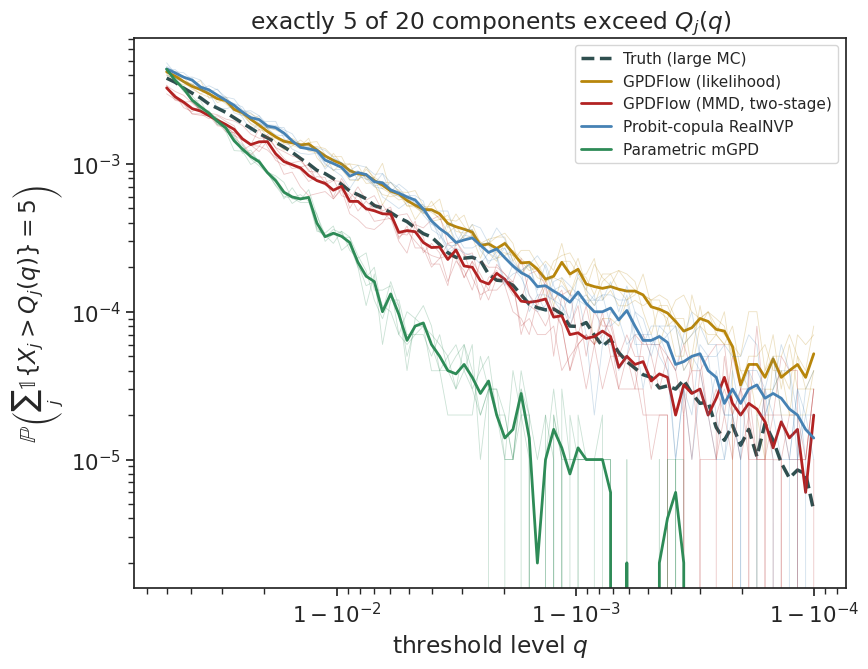

In [25]:
# --- Quantities 2 & 3: count-exceedance probability vs level q -------------
# P(exactly K_EXCEED of the d margins exceed their common-level threshold Q_j(q))
# as a function of q.  u_vec(q) = per-margin q-quantile of X_big; the SAME vector
# serves the truth (empirical probability) and every model (x p_cluster).
# Set K_EXCEED to the number of simultaneously exceeding components you want to
# see; K_EXCEED == dim is the "all d components exceed" case.
K_EXCEED = 5

fn_k = lambda X, u: prob_exactly_k_exceed(X, u, K_EXCEED)
tail = 'all d' if K_EXCEED == dim else f'exactly {K_EXCEED}'

p_k_true = prob_curve_true(X_big, U_MATS, fn_k)

curves = {}          # label -> dict(color, mean, per_fold)
for label, blocks, color in MODELS:
    mean_curve, per_fold = prob_curve_model(blocks, p_cluster_fit, U_MATS, fn_k)
    curves[label] = dict(color=color, mean=mean_curve, per_fold=per_fold)

ok = p_k_true > 0
print(f'P({tail} of {dim} exceed):')
print(f'  {"model":24s} {"LJPE":>9s} {"RMSLE_p":>9s}   (over q where truth > 0)')
for label, d in curves.items():
    print(f'  {label:24s} {cf.ljpe(d["mean"][ok], p_k_true[ok]):9.4f} '
          f'{cf.rmsle_p(d["mean"][ok], p_k_true[ok]):9.4f}')

sns.set(style='ticks', font_scale=1.4)
fig, ax = plt.subplots(figsize=(9, 7))

ax.plot(Q_GRID, p_k_true, '--', color=TRUTH_C, lw=2.5, label='Truth (large MC)')
for label, d in curves.items():
    for pf in d['per_fold']:
        ax.plot(Q_GRID, pf, color=d['color'], lw=0.6, alpha=0.25)
    ax.plot(Q_GRID, d['mean'], color=d['color'], lw=2, label=label)
ax.set_yscale('log')                            # probability on a log scale
ax.set_xscale('logit')                          # 0.9 / 0.99 / 0.999 evenly spaced
ax.set_xlabel(r'threshold level $q$')
ax.set_ylabel(rf'$\mathbb{{P}}\left(\sum_j \mathbb{{1}}\{{X_j > Q_j(q)\}} = {K_EXCEED}\right)$')
ax.set_title(f'{tail} of {dim} components exceed $Q_j(q)$')
ax.legend(fontsize=11)

fig.tight_layout()
plt.show()


quantile of M = max_j X_j   |   RMSE(log scale) vs empirical, q in [0.950, 1.000]
  GPDFlow (likelihood)     : 0.2151
  GPDFlow (MMD, two-stage) : 0.0988
  Probit-copula RealNVP    : 0.3600
  Parametric mGPD          : 0.4933


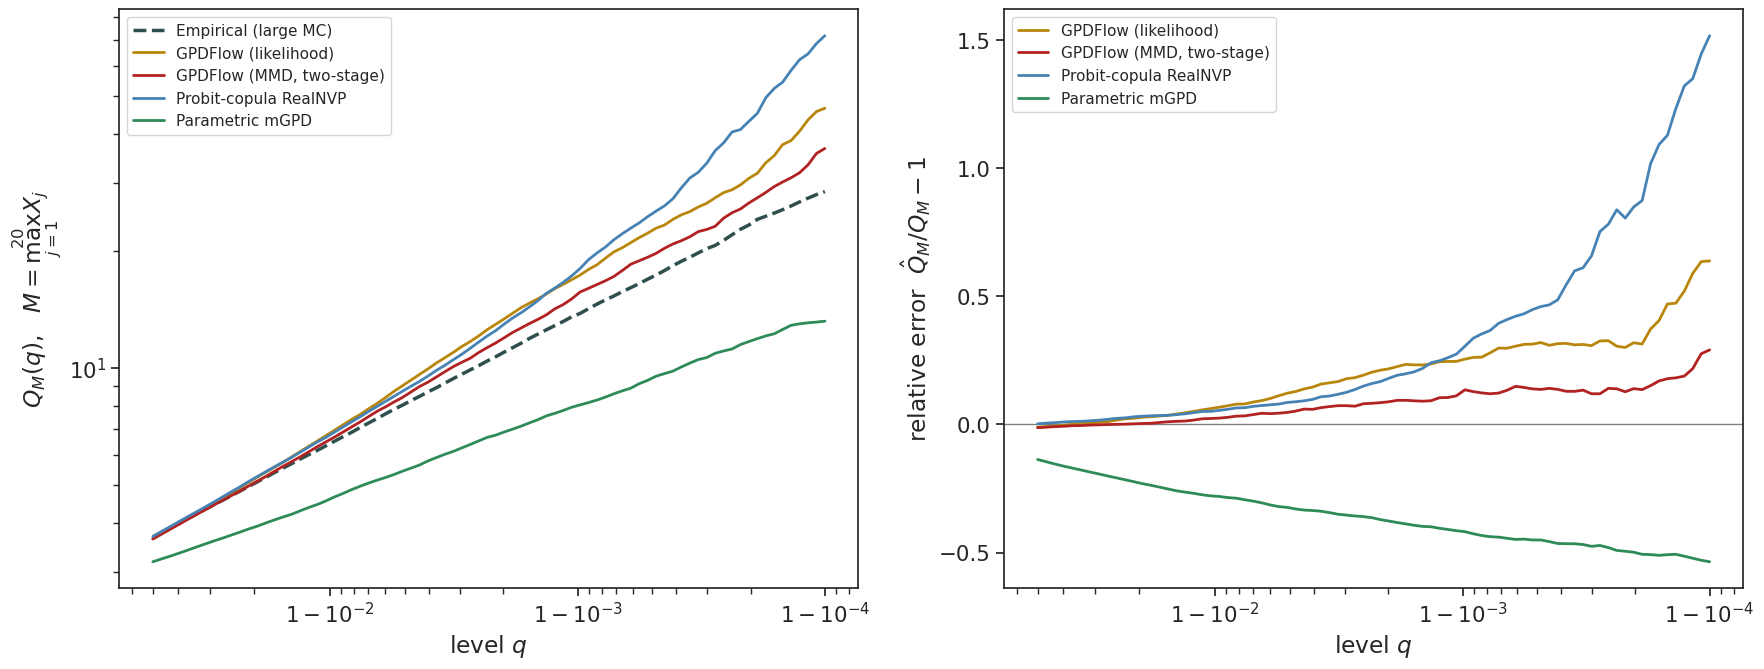

In [24]:
# --- Quantile of the componentwise maximum  M = max_j X_j  vs level q ------
# Empirical : unconditional q-quantile of M from the large MC sample.
# Model     : pooled cluster-conditional draws read at p_sim = 1-(1-q)/p_cluster
#             (exact here -- Q_M(q) >= max_j thres_j across the whole q grid,
#             since the 0.95 quantile of a 20-way max already sits above every
#             margin's 0.95 quantile).
qm_true   = max_component_quantile(X_big, Q_GRID)
qm_models = [(label, max_component_quantile(np.vstack(blocks), Q_GRID, p_cluster_fit), color)
             for label, blocks, color in MODELS]

print(f'quantile of M = max_j X_j   |   RMSE(log scale) vs empirical, '
      f'q in [{Q_GRID.min():.3f}, {Q_GRID.max():.3f}]')
for label, qm_hat, _ in qm_models:
    print(f'  {label:24s} : {cf.rmse_log_sigma(qm_hat, qm_true):.4f}')

sns.set(style='ticks', font_scale=1.4)
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

ax = axes[0]
ax.plot(Q_GRID, qm_true, '--', color=TRUTH_C, lw=2.5, label='Empirical (large MC)')
for label, qm_hat, color in qm_models:
    ax.plot(Q_GRID, qm_hat, color=color, lw=2, label=label)
ax.set_xscale('logit')
ax.set_yscale('log')
ax.set_xlabel(r'level $q$')
ax.set_ylabel(r'$Q_M(q)$,   $M = \max_{j=1}^{%d} X_j$' % dim)
ax.legend(fontsize=11)

ax = axes[1]
ax.axhline(0.0, color='gray', lw=1)
for label, qm_hat, color in qm_models:
    ax.plot(Q_GRID, qm_hat / qm_true - 1.0, color=color, lw=2, label=label)
ax.set_xscale('logit')
ax.set_xlabel(r'level $q$')
ax.set_ylabel(r'relative error  $\hat Q_M / Q_M - 1$')
ax.legend(fontsize=11)

fig.tight_layout()
plt.show()
